In [9]:
# import os
# # Set working directory manually on Gadi to be able to load csv files
# user = os.getenv('USER')
# os.chdir('/scratch/cd82/'+user+'/notebooks/')

## Checking Python packages

In [10]:
# !which python
# !where python

In [11]:
# Package installation if not already installed
# !pip install numpy
# !pip install scikit-learn

In [12]:
# import importlib
# import os

# packages = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'xgboost', 'shap']

# for pkg in packages:
#     try:
#         module = importlib.import_module(pkg)
#         path = os.path.dirname(module.__file__)
#         print(f"{pkg}: {path}")
#     except ImportError:
#         print(f"{pkg}: Not installed")

# Decision Tree Basics

Decision Trees are supervised learning models used for both classification and regression tasks. They work by recursively splitting the dataset based on feature values to reduce impurity.

## How It Works
- For **classification**, trees use metrics like **Gini impurity** or **Entropy** to decide the best split.
- For **regression**, they typically minimize **Mean Squared Error (MSE)**.

The tree starts at a root and splits the data into branches based on feature thresholds, creating a path to a decision leaf.

> ## 🔍 How Splitting Works in Decision Trees

### 🧪 Classification: Gini Impurity and Entropy

To decide the best feature and threshold to split on, decision trees evaluate **impurity** at each possible split. Lower impurity means a better split.

#### ✅ Gini Impurity

Gini measures how often a randomly chosen element would be incorrectly labeled if it was randomly labeled according to the distribution in the node:

$$
\text{Gini} = 1 - \sum_{i=1}^{C} p_i^2
$$

Where:
- $ C $ is the number of classes  
- $ p_i $ is the proportion of class $ i $

#### ✅ Entropy (Information Gain)

Entropy measures the disorder or uncertainty of the classes:

$$
\text{Entropy} = - \sum_{i=1}^{C} p_i \log_2(p_i)
$$

A split is chosen to **minimize the weighted impurity** (Gini or Entropy) of the resulting child nodes.

---

### 📈 Regression: Mean Squared Error (MSE)

In regression trees, the quality of a split is measured using **Mean Squared Error**, which calculates how far predictions are from actual values.

#### ✅ MSE Formula

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2
$$

Where:
- $ y_i $ are the true values  
- $ \bar{y} $ is the mean value of the current region  
- $ n $ is the number of samples

The best split minimizes the **total MSE** across the child nodes.

---

### 🎯 Final Prediction

- **Classification Tree**: predicts the **majority class** in a leaf.
- **Regression Tree**: predicts the **mean target value** of samples in a leaf.


## Key Hyperparameters
- `max_depth`: Maximum number of splits down any path.
- `min_samples_split`: Minimum samples needed to split a node.
- `min_samples_leaf`: Minimum samples in a leaf node.
- `criterion`: Splitting metric (`gini`, `entropy`, `squared_error`).

### Importing packages

In [13]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
# import seaborn as sns
%matplotlib inline

# Classification on Heart Disease dataset 

In [14]:
# Load and prepare the dataset
data_url = "https://raw.githubusercontent.com/qcif-training/decision-tree-methods/main/heart.csv"
df = pd.read_csv(data_url)

df = (
    df.drop(columns=["id", "dataset"])
      .rename(columns={"thalch": "thalach", "num": "target"})
)
df["target"] = (df["target"] > 0).astype(int)
df = pd.get_dummies(df, drop_first=True, dtype=int)
df = df.fillna(df.median(numeric_only=True))

# Display dataframe
display(df.head())

,age,trestbps,chol,thalach,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,1,0,0,1,1,0,0,0,0,0,0,0
1,67,160.0,286.0,108.0,1.5,3.0,1,1,0,0,0,0,0,0,1,1,0,1,0
2,67,120.0,229.0,129.0,2.6,2.0,1,1,0,0,0,0,0,0,1,1,0,0,1
3,37,130.0,250.0,187.0,3.5,0.0,0,1,0,1,0,0,1,0,0,0,0,1,0
4,41,130.0,204.0,172.0,1.4,0.0,0,0,1,0,0,0,0,0,0,0,1,1,0


target (or sometimes named num in original datasets):

Binary classification:

0 → No heart disease

1 → Heart disease present


| Column Name | Description                                                        |
| ----------- | ------------------------------------------------------------------ |
| `age`       | Age in years                                                       |
| `sex`       | Sex (1 = male; 0 = female)                                         |
| `cp`        | Chest pain type (0–3, categorical: typical angina to asymptomatic) |
| `trestbps`  | Resting blood pressure (in mm Hg)                                  |
| `chol`      | Serum cholesterol in mg/dl                                         |
| `fbs`       | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)              |
| `restecg`   | Resting electrocardiographic results (0, 1, 2)                     |
| `thalach`   | Maximum heart rate achieved                                        |
| `exang`     | Exercise-induced angina (1 = yes; 0 = no)                          |
| `oldpeak`   | ST depression induced by exercise relative to rest                 |
| `slope`     | Slope of the peak exercise ST segment (0–2)                        |
| `ca`        | Number of major vessels colored by fluoroscopy (0–3)               |
| `thal`      | Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect)  |


In [15]:
# show numerical columns
display(df.describe())


,age,trestbps,chol,thalach,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.227174,0.553261,0.789130,0.189130,0.221739,0.050000,0.150000,0.598913,0.194565,0.366304,0.375000,0.220652,0.213043,0.208696
std,9.424685,18.451300,109.040171,25.145235,1.058049,0.628936,0.497426,0.408148,0.391825,0.415642,0.218063,0.357266,0.490385,0.396081,0.482056,0.484386,0.414912,0.409681,0.406597
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


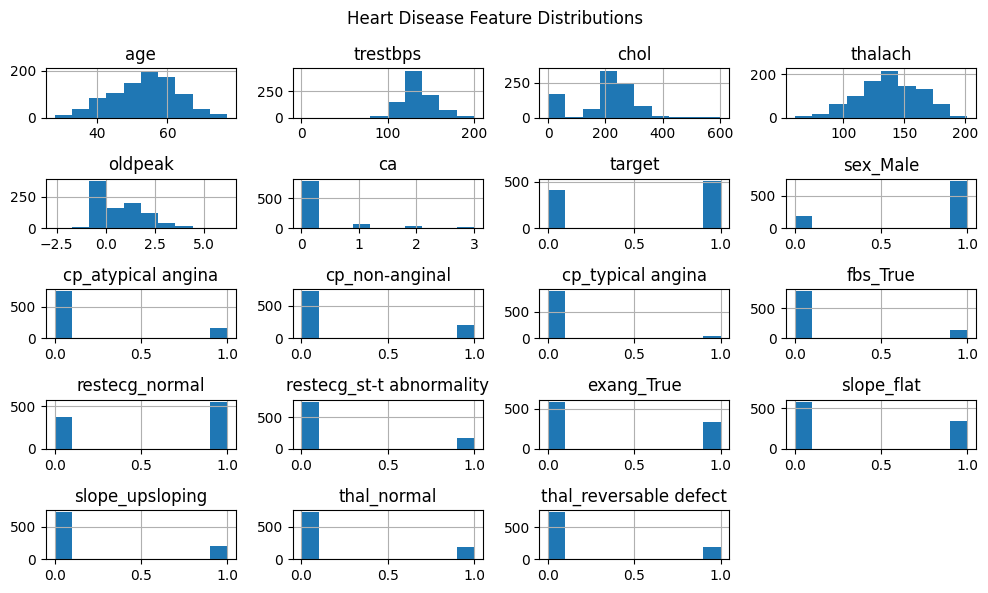

In [16]:
df.hist(figsize=(10,6))
plt.suptitle('Heart Disease Feature Distributions')
plt.tight_layout()
plt.show()


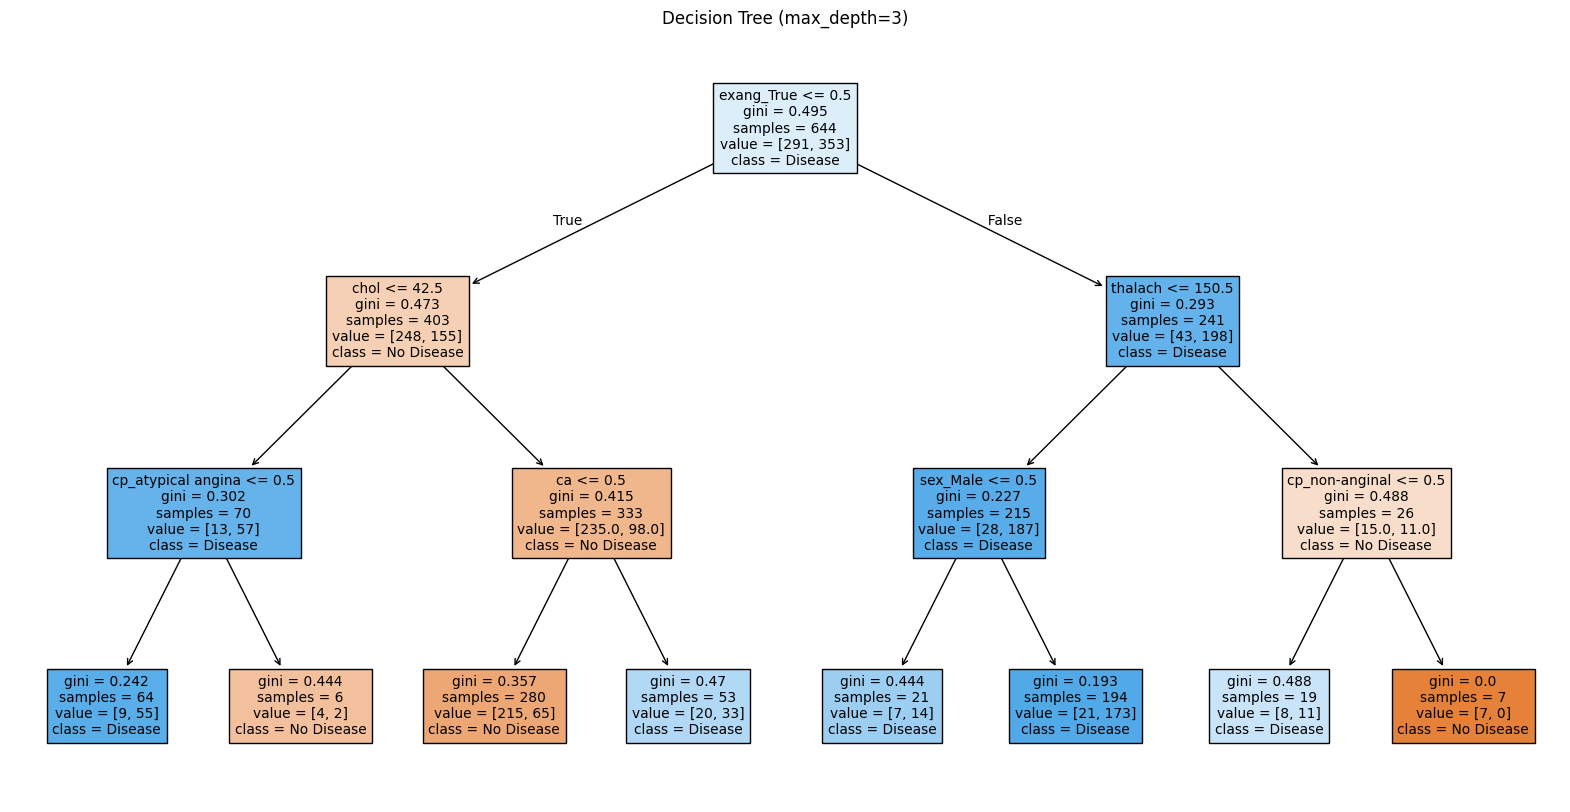

In [17]:
# Split the prepared dataset into features and target
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree (max_depth=3)")
plt.show()

Accuracy: 0.79


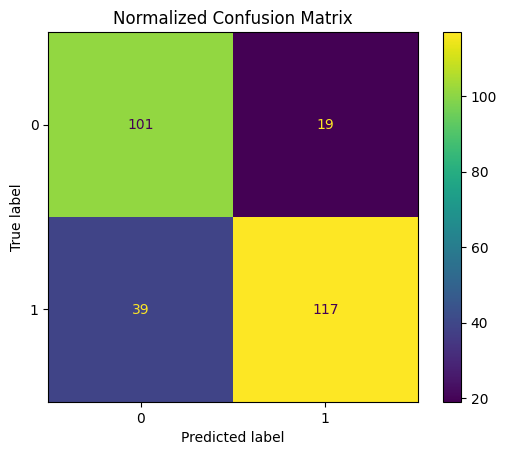

In [18]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score

# Predict on test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display
print(f"Accuracy: {accuracy:.2f}")

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Normalized Confusion Matrix")
plt.show()


# Regression with California Housing

In [19]:
# Load regression dataset (California housing)
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [20]:
# California Housing dataset
display(df.head())


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


MedHouseVal: Median house value (in hundreds of thousands of dollars).
For example, a value of 2.5 means $250,000.

| Feature Name | Description                                                    |
| ------------ | -------------------------------------------------------------- |
| `MedInc`     | Median income in block group (in tens of thousands of dollars) |
| `HouseAge`   | Median age of houses in the block group                        |
| `AveRooms`   | Average number of rooms per household                          |
| `AveBedrms`  | Average number of bedrooms per household                       |
| `Population` | Block group population                                         |
| `AveOccup`   | Average number of household members                            |
| `Latitude`   | Latitude of the block group (geographic location)              |
| `Longitude`  | Longitude of the block group (geographic location)             |


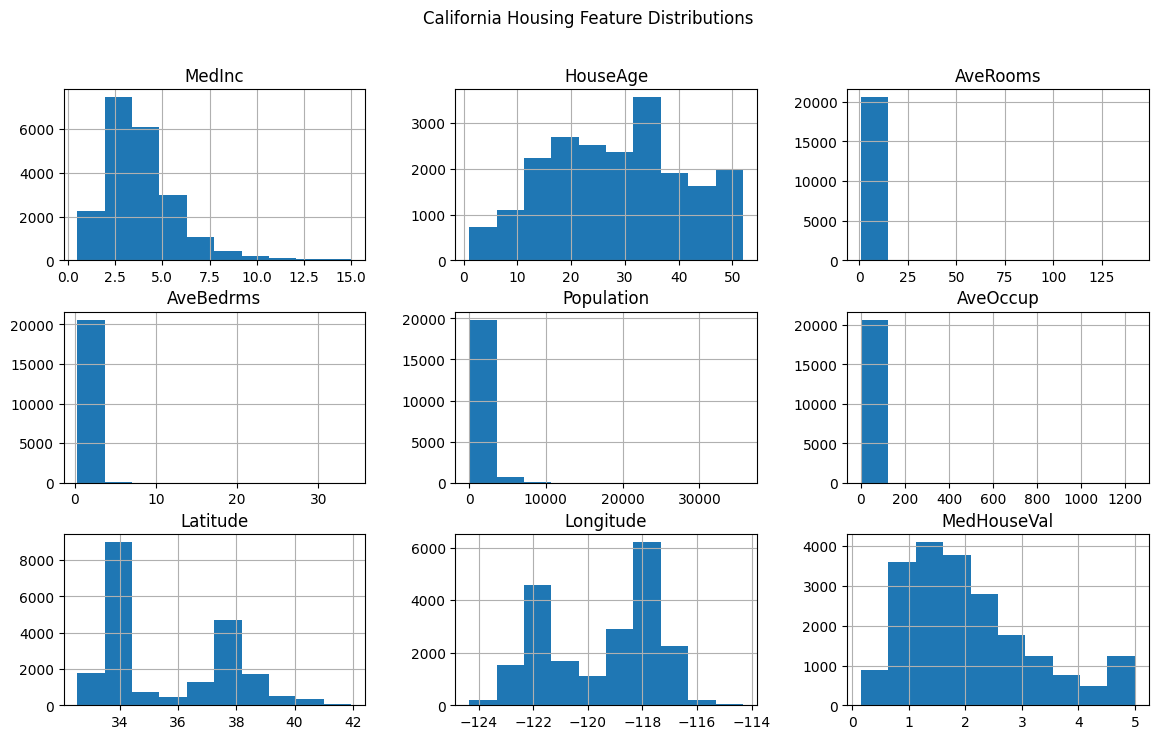

In [21]:
df.hist(figsize=(14,8))
plt.suptitle('California Housing Feature Distributions')
plt.show()


In [22]:
# Train a Decision Tree Regressor
X = housing.data
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=3, random_state=42)

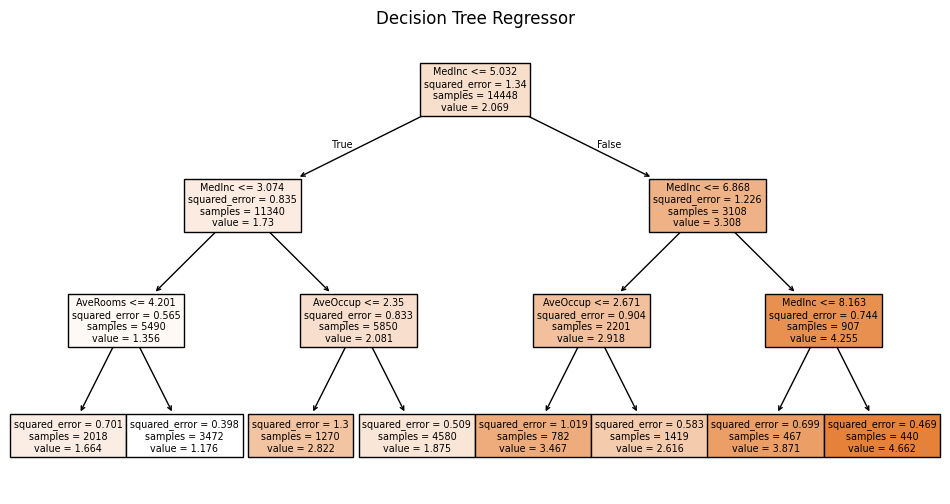

In [23]:
plt.figure(figsize=(12, 6))
plot_tree(reg, feature_names=housing.feature_names, filled=True)
plt.title('Decision Tree Regressor')
plt.show()

### What is R² (Coefficient of Determination)?

The R² score measures how well the predictions of a regression model approximate the actual data. It is defined as:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

Where:
- $ y_i $ are the actual values,
- $ \hat{y}_i $ are the predicted values,
- $ \bar{y} $ is the mean of the actual values.

**Interpretation:**
- $ R^2 = 1 $: perfect prediction
- $ R^2 = 0 $: model predicts no better than the mean
- $ R^2 < 0 $: model performs worse than predicting the mean


In [24]:
from sklearn.metrics import r2_score

# Predict on test set
y_pred = reg.predict(X_test)

# Calculate R²
r2 = r2_score(y_test, y_pred)

# Display
print(f"R² Score: {r2:.2f}")


R² Score: 0.52
